# NERVE Raw Data Exploration

Download the default **small** session and inspect how RGB, depth, events, radar, and COCO annotations are laid out on disk. This mirrors the structure inside each session `.tar.gz` from 4TU.ResearchData.

In [1]:
from nerve import config, remote
from nerve.registry import all_sessions
from importlib.resources import files
from pathlib import Path
import json

sessions = all_sessions()
smallest = min(sessions, key=lambda s: s.size_bytes)
print(f"Smallest session: {smallest.name}  "
      f"({smallest.size_bytes / 1e9:.2f} GB archive, split={smallest.split})")

session_dir = remote.download_session(smallest.name)
SESSION = Path(session_dir)
print(f"Session path: {SESSION}")


Smallest session: 2023-10-26_15-37-59  (0.40 GB archive, split=train)
  Session already exists: /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59
Session path: /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59


## Session archive structure

After extraction you should see (names may vary slightly by capture):

- `session_metadata.json` -- high-level session info
- `rgb/`containing `annotations/annotations.json` from a pretrained model
- `davis/` or `davis346` paths -- `events.hdf5` for DAVIS events and `annotations/annotations.json` containing projected rgb labels
- `prophesee/`-- `annotations/annotations.json` containing projected rgb labels
- `prophesee/events.hdf5` -- Prophesee events 
- `L515_depth.mp4` -- depth video 
- `ti_radar/captured_data/set000/data.h5` -- radar ADC / metadata
- `timings.json` -- per-sensor timing anchors 


In [2]:
import json

meta = session_dir / "session_metadata.json"
if meta.is_file():
    print(json.dumps(json.loads(meta.read_text(encoding="utf-8")), indent=2))
else:
    print("No session_metadata.json found. Top-level entries:")
    for p in sorted(session_dir.iterdir()):
        print(" ", p.name)

{
  "@context": {
    "sml": "http://www.opengis.net/sensorml/2.0",
    "gml": "http://www.opengis.net/gml/3.2",
    "swe": "http://www.opengis.net/swe/2.0"
  },
  "sml:System": {
    "gml:identifier": {
      "codeSpace": "urn:nerve:session",
      "value": "2023_10_26/2023-10-26_15-37-59"
    },
    "gml:name": "2023-10-26_15-37-59",
    "sml:validTime": {
      "gml:TimePeriod": {
        "gml:beginPosition": "2023-10-26T15:37:59",
        "gml:endPosition": "2023-10-26T15:38:14.096000",
        "duration_seconds": 15.096,
        "duration_formatted": "0m 15s"
      }
    },
    "sml:components": [
      {
        "sml:Component": {
          "gml:name": "DAVIS346",
          "sml:typeOf": "EventCamera",
          "sml:description": "iniVation DAVIS346 Dynamic Vision Sensor with grayscale frames",
          "sml:characteristics": {
            "manufacturer": "iniVation",
            "model": "DAVIS346",
            "sensor_type": "DVS + APS",
            "resolution_width": 346,
 

## Event camera data (DAVIS)

Events are stored in HDF5, usually under `davis/events.hdf5`, dataset `events` with fields such as `t`, `x`, `y`, `p` and file-level attributes (`total_events`, `width`, `height`, etc.).

Keys: ['events', 'support_indexes']
events shape: (459160,)
dtype: {'names': ['t', 'x', 'y', 'p'], 'formats': ['<i8', '<u2', '<u2', 'i1'], 'offsets': [0, 8, 10, 12], 'itemsize': 16}
  events.attr height: 260
  events.attr name: DAVIS346
  events.attr total_events: 459160
  events.attr total_time_uS: 14482845
  events.attr width: 346
event count (attr / len): 459160 459160


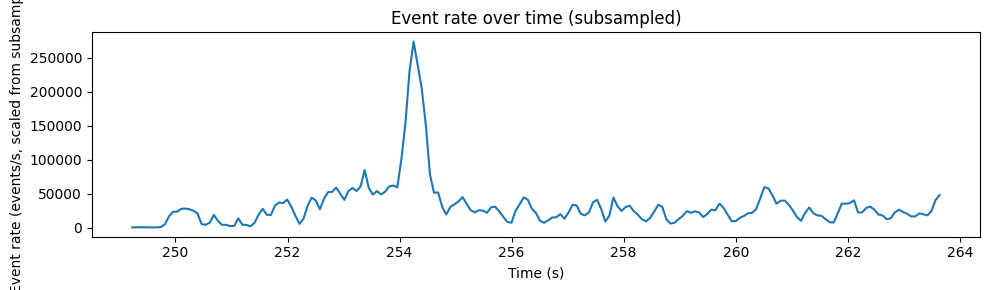

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

ev_path = session_dir / "davis" / "events.hdf5"
if not ev_path.is_file():
    raise FileNotFoundError(f"Missing {ev_path} -- run the download cell first.")

with h5py.File(ev_path, "r") as f:
    print("Keys:", list(f.keys()))
    ev = f["events"]
    print("events shape:", ev.shape)
    print("dtype:", ev.dtype)
    for k in f.attrs:
        print(f"  attr {k}: {f.attrs[k]}")
    for k in ev.attrs:
        print(f"  events.attr {k}: {ev.attrs[k]}")
    n = int(ev.attrs.get("total_events", len(ev)))
    print("event count (attr / len):", n, len(ev))
    # Sample slice for rate plot (adjust for very large files)
    step = max(1, len(ev) // 500_000)
    t = ev["t"][::step]
    if t.size:
        t0, t1 = float(t.min()), float(t.max())
        bins = max(50, int((t1 - t0) / max(1e3, (t1 - t0) / 200)))
        hist, edges = np.histogram(t, bins=bins)
        centers = (edges[:-1] + edges[1:]) / 2
        rate = hist / np.diff(edges)  # events per microsecond
        plt.figure(figsize=(10, 3))
        plt.plot(centers * 1e-6, rate * 1e6)  # seconds vs events/s
        plt.xlabel("Time (s)")
        plt.ylabel("Event rate (events/s, scaled from subsample)")
        plt.title("Event rate over time (subsampled)")
        plt.tight_layout()
        plt.show()

### Accumulated event frames

To visualize what the event camera actually "sees", we accumulate all events over a time window into a single frame. White pixels represent positive polarity changes (brightness increase), black pixels represent negative polarity changes (brightness decrease), and grey is the neutral background (no events).

We compare two 4-second windows: one near the peak of the event rate plot above (252 - 256 s) and one from a quieter period (258 - 262 s).

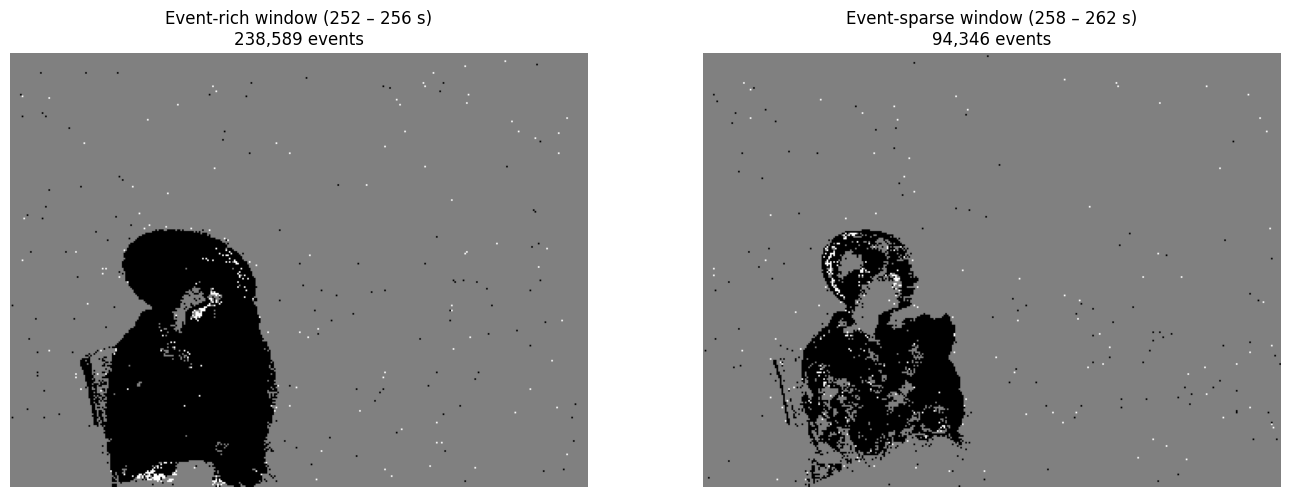

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

ev_path = session_dir / "davis" / "events.hdf5"

with h5py.File(ev_path, "r") as f:
    ev = f["events"]
    W, H = int(ev.attrs["width"]), int(ev.attrs["height"])
    t_all = ev["t"][:]
    x_all = ev["x"][:]
    y_all = ev["y"][:]
    p_all = ev["p"][:]

    windows = [
        (252, 256, "Event-rich window (252 - 256 s)"),
        (258, 262, "Event-sparse window (258 - 262 s)"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (t_lo, t_hi, title) in zip(axes, windows):
        lo_us, hi_us = t_lo * 1_000_000, t_hi * 1_000_000
        mask = (t_all >= lo_us) & (t_all < hi_us)
        n_events = mask.sum()

        frame = np.full((H, W, 3), 128, dtype=np.uint8)
        if n_events > 0:
            xs, ys, ps = x_all[mask], y_all[mask], p_all[mask]
            frame[ys[ps > 0], xs[ps > 0]] = [255, 255, 255]
            frame[ys[ps <= 0], xs[ps <= 0]] = [0, 0, 0]

        ax.imshow(frame)
        ax.set_title(f"{title}\n{n_events:,} events")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## RGB-D data (Intel L515)

RGB in the future may appear as numbered frames under `rgb/images/` or as `L515_rgb.mp4` at the session root if it is possible to anonymize all faces reliably. Depth is commonly stored as `L515_depth.mp4`.

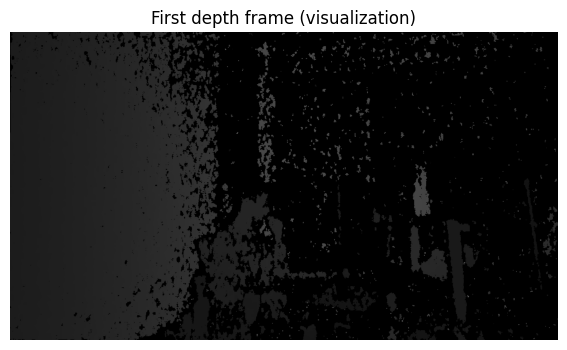

In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


depth_mp4 = session_dir / "L515_depth.mp4"
if depth_mp4.is_file():
    import cv2
    cap = cv2.VideoCapture(str(depth_mp4))
    ok, frame = cap.read()
    cap.release()
    if ok:
        # Often single-channel or BGR-encoded depth visualization
        plt.figure(figsize=(8, 4))
        if frame.ndim == 3:
            plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(frame, cmap="magma")
        plt.title("First depth frame (visualization)")
        plt.axis("off")
        plt.show()
    else:
        print("Could not read first depth frame")
else:
    print("No L515_depth.mp4 at session root")

## Radar data (TI AWR1443BOOST)

Raw radar is stored in HDF5 under `ti_radar/captured_data/set000/data.h5`. Datasets are organized under groups such as `radar/dataset_1/` (including `timestamps`). Inspect shapes below.

In [6]:
import h5py

radar_h5 = session_dir / "ti_radar" / "captured_data" / "set000" / "data.h5"
if not radar_h5.is_file():
    raise FileNotFoundError(radar_h5)

def describe(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"  Dataset {name} shape={obj.shape} dtype={obj.dtype}")

with h5py.File(radar_h5, "r") as f:
    print("File:", radar_h5)
    f.visititems(describe)
    # Common path for raw cube (name may vary slightly)
    for candidate in ("radar/dataset_1/data", "radar/dataset_1/adc", "radar/data"):
        if candidate in f:
            d = f[candidate]
            print("\nPrimary tensor candidate:", candidate, "shape", d.shape, "dtype", d.dtype)
            break

File: /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59/ti_radar/captured_data/set000/data.h5
  Dataset radar/dataset_1/data shape=(149, 128, 3, 4, 256, 2) dtype=int16
  Dataset radar/dataset_1/sequencenumbers shape=(149,) dtype=uint64
  Dataset radar/dataset_1/timestamps shape=(149,) dtype=float64
  Dataset radar/dataset_1/validflags shape=(149,) dtype=uint8

Primary tensor candidate: radar/dataset_1/data shape (149, 128, 3, 4, 256, 2) dtype int16


### Range-Doppler map and 3-D radar point cloud

FMCW radar captures raw ADC samples organised as `(frames, chirp_loops, TX, RX, ADC_samples, I/Q)`. A `RadarBackend` implementation (see `nerve/radar/interface.py`) runs the full FMCW DSP processing chain:

1. **Range FFT** -- fast-time FFT converts each chirp into a range profile.
2. **Doppler FFT** -- slow-time FFT reveals radial velocity at each range bin.
3. **MIMO decoding & equalization** -- maps TX×RX channels onto a virtual antenna array.
4. **CFAR detection** -- adaptive thresholding extracts targets from noise.
5. **Angle-of-Arrival (AoA) beamforming** -- resolves azimuth and elevation to produce **3-D Cartesian point clouds** per frame.

Below we iterate over all frames to collect the aggregated point cloud and show the Range-Doppler map from the middle frame.

> **Note:** The underlying radar DSP library is proprietary and **cannot be redistributed** due to copyright restrictions. It is therefore not included in this repository. Users who do not have access to it can implement their own radar backend by subclassing the abstract interface at [`nerve/radar/interface.py`](../nerve/radar/interface.py) and registering it in [`nerve/radar/__init__.py`](../nerve/radar/__init__.py). The cell below will be skipped if the library is not installed.

AttributeError: _ARRAY_API not found

AttributeError: _ARRAY_API not found

AttributeError: _ARRAY_API not found

Recording: 149 frames at 11.1 Hz
Total detections: 1799 across 149 frames (min 6, max 42, mean 12.1 per frame)


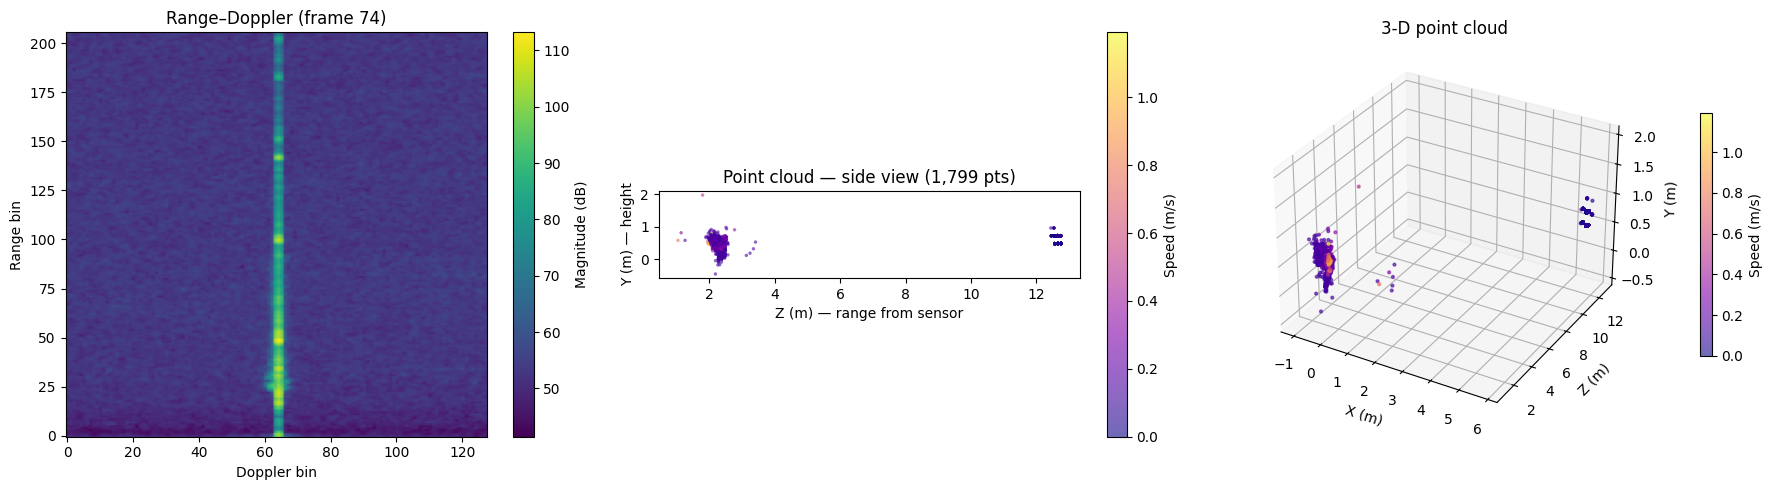

In [2]:
import sys, os, warnings, contextlib

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

# Suppress noisy stderr during import and processing
with contextlib.redirect_stderr(open(os.devnull, "w")):
    from nerve.radar import get_backend

    # ── Load recording via abstraction layer ───────────────────────────
    ti_radar_dir = str(session_dir / "ti_radar")
    Backend = get_backend()
    radar = Backend.from_recording(ti_radar_dir)

num_frames = radar.get_num_frames()
fps = 1.0 / radar.get_frame_period()
print(f"Recording: {num_frames} frames at {fps:.1f} Hz")

# ── Process all frames ───────────────────────────────────────
all_coords, all_vels, frame_counts = [], [], []
rd_snapshot = None
mid = num_frames // 2

with contextlib.redirect_stderr(open(os.devnull, "w")):
    for i in range(num_frames):
        pc = radar.get_point_cloud(i)
        coords = pc[:, :3] if pc.shape[1] >= 3 else pc
        vels = pc[:, 3:] if pc.shape[1] > 3 else np.empty((len(pc), 0))
        all_coords.append(coords)
        all_vels.append(vels)
        frame_counts.append(len(coords))
        if i == mid:
            rd_snapshot = np.abs(radar.get_range_doppler(i)).astype(np.float64)
            snap_seq = i

radar.close()

pts = np.concatenate(all_coords, axis=0).astype(np.float32)
vel = np.concatenate(all_vels, axis=0).astype(np.float32)
speed = np.linalg.norm(vel, axis=1)
print(f"Total detections: {len(pts)} across {len(frame_counts)} frames "
      f"(min {min(frame_counts)}, max {max(frame_counts)}, "
      f"mean {np.mean(frame_counts):.1f} per frame)")

# ── Range-Doppler map (middle frame, averaged over virtual antennas) ──
rd_2d = rd_snapshot.mean(axis=(1, 2))
rd_db = 20 * np.log10(rd_2d + 1e-12)

# ── Plot ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 5))

# 1. Range-Doppler map
ax1 = fig.add_subplot(1, 3, 1)
im = ax1.imshow(rd_db.T, aspect="auto", cmap="viridis", origin="lower")
fig.colorbar(im, ax=ax1, label="Magnitude (dB)")
ax1.set_xlabel("Doppler bin")
ax1.set_ylabel("Range bin")
ax1.set_title(f"Range-Doppler (frame {snap_seq})")

# 2. Point cloud -- side view (Z vs Y)
ax2 = fig.add_subplot(1, 3, 2)
sc = ax2.scatter(pts[:, 2], pts[:, 1], c=speed, cmap="plasma",
                 s=6, alpha=0.6, edgecolors="none")
fig.colorbar(sc, ax=ax2, label="Speed (m/s)")
ax2.set_xlabel("Z (m) -- range from sensor")
ax2.set_ylabel("Y (m) -- height")
ax2.set_title(f"Point cloud -- side view ({len(pts):,} pts)")
ax2.set_aspect("equal")

# 3. 3-D point cloud
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
sc3 = ax3.scatter(pts[:, 0], pts[:, 2], pts[:, 1], c=speed,
                  cmap="plasma", s=4, alpha=0.6)
fig.colorbar(sc3, ax=ax3, label="Speed (m/s)", shrink=0.6, pad=0.12)
ax3.set_xlabel("X (m)")
ax3.set_ylabel("Z (m)")
ax3.set_zlabel("Y (m)")
ax3.set_title("3-D point cloud")

plt.tight_layout()
plt.show()

## Radar data (Infineon Position2Go)

The Infineon Position2Go 24 GHz FMCW radar is co-recorded with the DAVIS346 event camera inside a single `.rad` TLV binary file (`radar_and_davis346_events.rad`). While the DVS events from this file are converted to HDF5 separately (see walkthrough 02b), the **radar ADC frames** can be extracted and converted into a similar fomrat as the TI Radar using the `rad_radar_to_radardb` converter.


### Range-Doppler map and 3-D point cloud (Infineon)

Same DSP chain as the TI radar above, but applied to the converted Position2Go data. The Position2Go is a 1TX × 2RX, 24 GHz radar with ~200 MHz bandwidth (~0.9 m range resolution) which means it is coarser than the TI radar and may not detect as much.

Recording: 15 frames at 4.0 Hz
Total detections: 0 across 15 frames (min 0, max 0, mean 0.0 per frame)


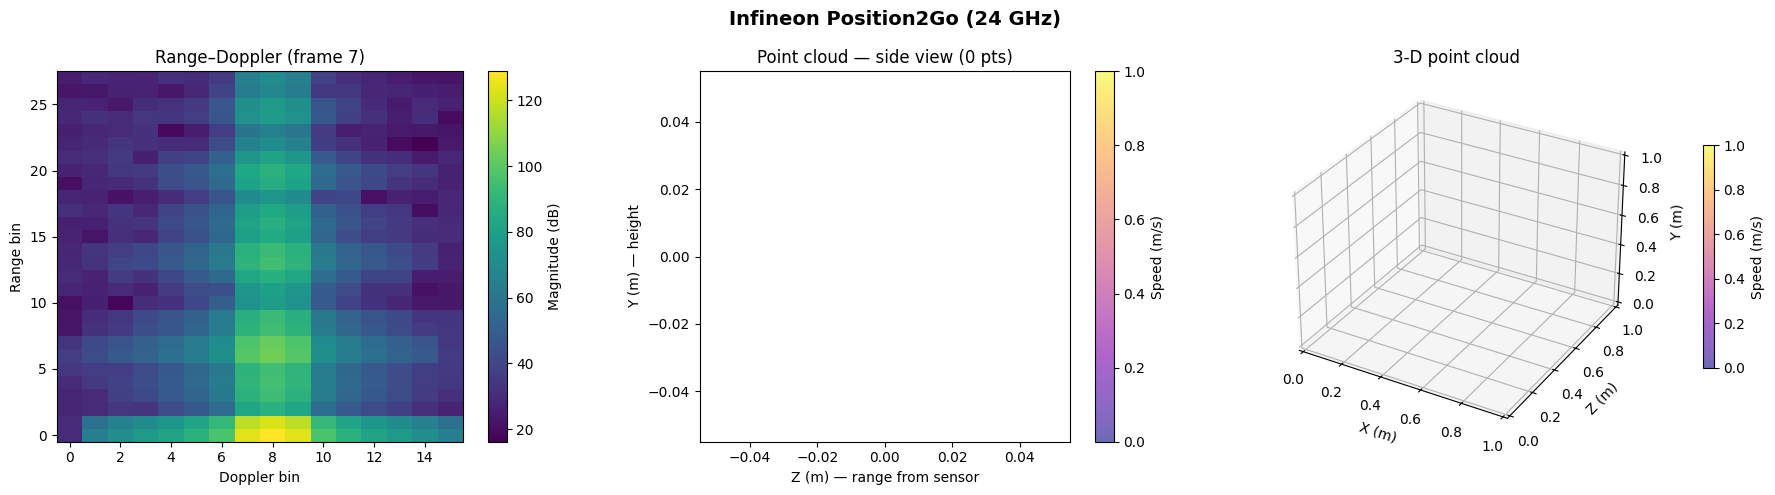

In [ ]:
import sys, os, warnings, contextlib

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

infineon_radardb_dir = session_dir / "infineon_radar"

if not (infineon_radardb_dir / "recording.xml").is_file():
    print("⚠ Infineon radardb recording not found -- run the conversion cell above first.")
else:
    try:
        with contextlib.redirect_stderr(open(os.devnull, "w")):
            from nerve.radar import get_backend

            Backend = get_backend()
            radar = Backend.from_recording(str(infineon_radardb_dir))

        num_frames = radar.get_num_frames()
        fps = 1.0 / radar.get_frame_period()
        print(f"Recording: {num_frames} frames at {fps:.1f} Hz")

        all_coords, all_vels, frame_counts = [], [], []
        rd_snapshot = None
        mid = num_frames // 2

        with contextlib.redirect_stderr(open(os.devnull, "w")):
            for i in range(num_frames):
                pc = radar.get_point_cloud(i)
                coords = pc[:, :3] if pc.shape[1] >= 3 else pc
                vels = pc[:, 3:] if pc.shape[1] > 3 else np.empty((len(pc), 0))
                all_coords.append(coords)
                all_vels.append(vels)
                frame_counts.append(len(coords))
                if i == mid:
                    rd_snapshot = np.abs(radar.get_range_doppler(i)).astype(np.float64)
                    snap_seq = i

        radar.close()

        pts = np.concatenate(all_coords, axis=0).astype(np.float32)
        vel = np.concatenate(all_vels, axis=0).astype(np.float32)
        speed = np.linalg.norm(vel, axis=1)
        print(f"Total detections: {len(pts)} across {len(frame_counts)} frames "
              f"(min {min(frame_counts)}, max {max(frame_counts)}, "
              f"mean {np.mean(frame_counts):.1f} per frame)")

        # ── Range-Doppler map (middle frame, averaged over virtual antennas) ──
        rd_2d = rd_snapshot.mean(axis=(1, 2))
        rd_db = 20 * np.log10(rd_2d + 1e-12)

        # ── Plot ─────────────────────────────────────────────────────
        fig = plt.figure(figsize=(18, 5))
        fig.suptitle("Infineon Position2Go (24 GHz)", fontsize=14, fontweight="bold")

        # 1. Range-Doppler map
        ax1 = fig.add_subplot(1, 3, 1)
        im = ax1.imshow(rd_db.T, aspect="auto", cmap="viridis", origin="lower")
        fig.colorbar(im, ax=ax1, label="Magnitude (dB)")
        ax1.set_xlabel("Doppler bin")
        ax1.set_ylabel("Range bin")
        ax1.set_title(f"Range-Doppler (frame {snap_seq})")

        # 2. Point cloud -- side view (Z vs Y)
        ax2 = fig.add_subplot(1, 3, 2)
        sc = ax2.scatter(pts[:, 2], pts[:, 1], c=speed, cmap="plasma",
                         s=6, alpha=0.6, edgecolors="none")
        fig.colorbar(sc, ax=ax2, label="Speed (m/s)")
        ax2.set_xlabel("Z (m) -- range from sensor")
        ax2.set_ylabel("Y (m) -- height")
        ax2.set_title(f"Point cloud -- side view ({len(pts):,} pts)")
        ax2.set_aspect("equal")

        # 3. 3-D point cloud
        ax3 = fig.add_subplot(1, 3, 3, projection="3d")
        sc3 = ax3.scatter(pts[:, 0], pts[:, 2], pts[:, 1], c=speed,
                          cmap="plasma", s=4, alpha=0.6)
        fig.colorbar(sc3, ax=ax3, label="Speed (m/s)", shrink=0.6, pad=0.12)
        ax3.set_xlabel("X (m)")
        ax3.set_ylabel("Z (m)")
        ax3.set_zlabel("Y (m)")
        ax3.set_title("3-D point cloud")

        plt.tight_layout()
        plt.show()

    except ImportError:
        print("⚠ Radar DSP library not available -- skipping point cloud extraction.")
        print("  The HDF5 data was written successfully (see cell above).")
        print("  Install the required DSP library or implement a custom RadarBackend to process it.")
    except Exception as e:
        print(f"⚠ Error during Infineon radar processing: {e}")
        import traceback
        traceback.print_exc()